In [45]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 64
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:41: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(alphas[0])
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:41: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats

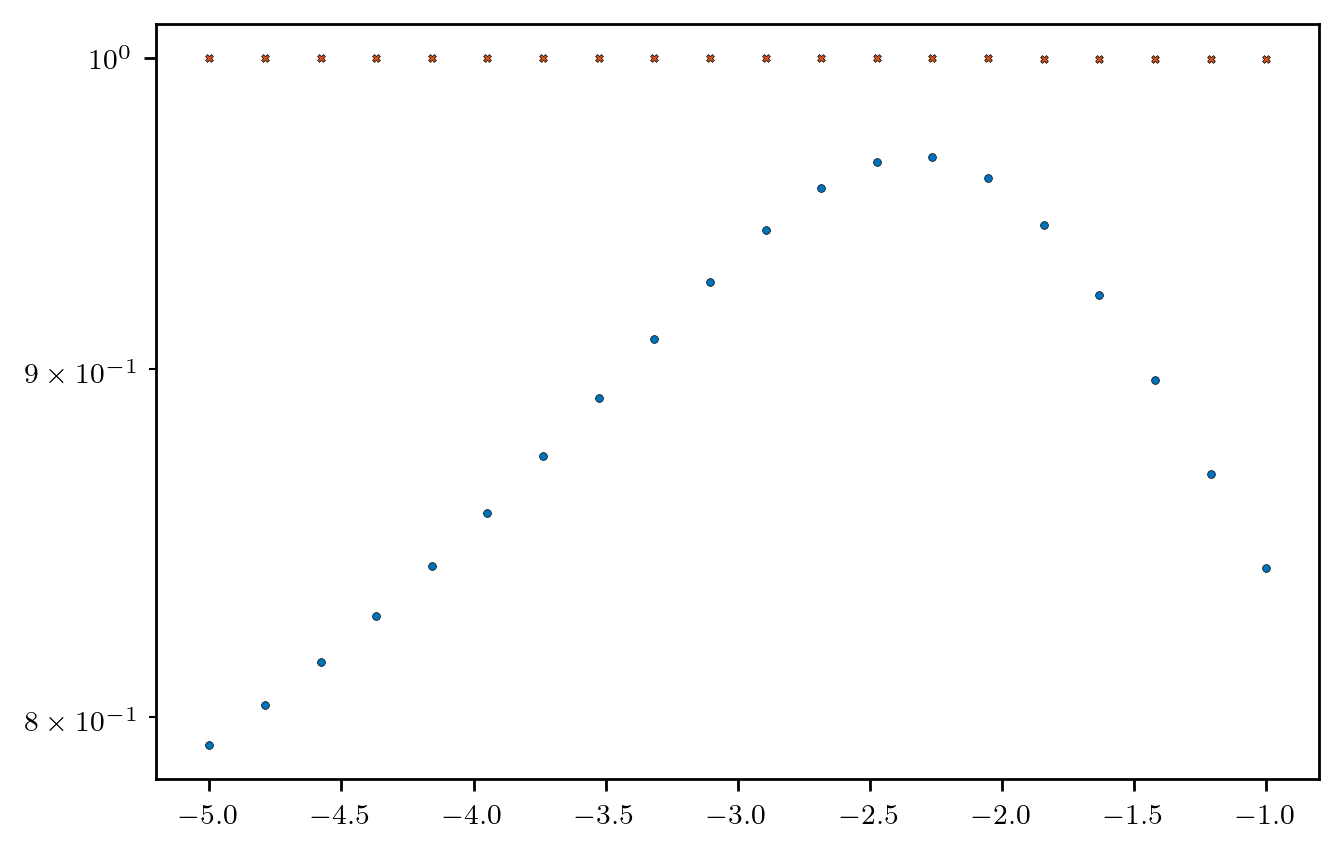

In [46]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))
energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))

specs = []
Pspecs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, lenn=phys_dims)
    _km, _fekm, width = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='center',
            cut_excess=True, nan_small=False)
    Pspecs.append((_km, _fekm))

    lags = arevalo_spectra.k_to_discrete_lags(_km, N, L)
    km, fekm = arevalo_spectra.modal_spectrum(f, lenn=phys_dims, lags=lags, mode='wrap')
    specs.append((km, fekm))

    e_parsevals = np.nansum(statistics_base.kern(km, D, width, dk) * fekm * (dk/twopi)**D)

    # * (dk/twopi)**D
    plt.scatter(alphas[i], e_parsevals, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    plt.scatter(alphas[i], energies[i], marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')
    #assert np.isclose(e_parsevals / energies[i], 1., rtol=0.001), e_parsevals / energies[i]

plt.yscale('log')
#plt.ylim((9e-1, 1.1e0))

In [47]:
cols = plt.cm.Greys(np.linspace(0.5, 1., NUM))

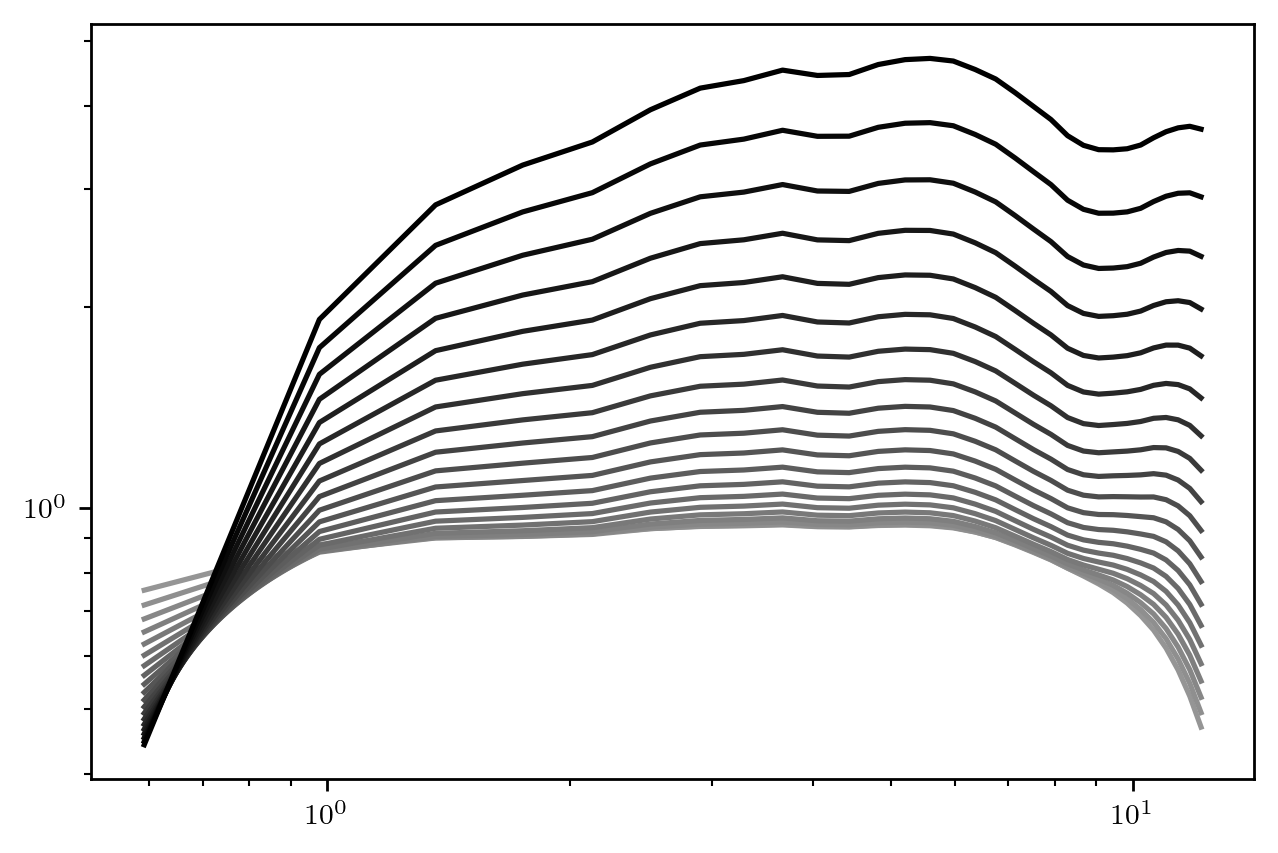

In [55]:
for i in range(len(specs)):
    pk, pfek = Pspecs[i]
    ak, afek = specs[i]
    plt.loglog(ak, afek / pfek, color=cols[i])

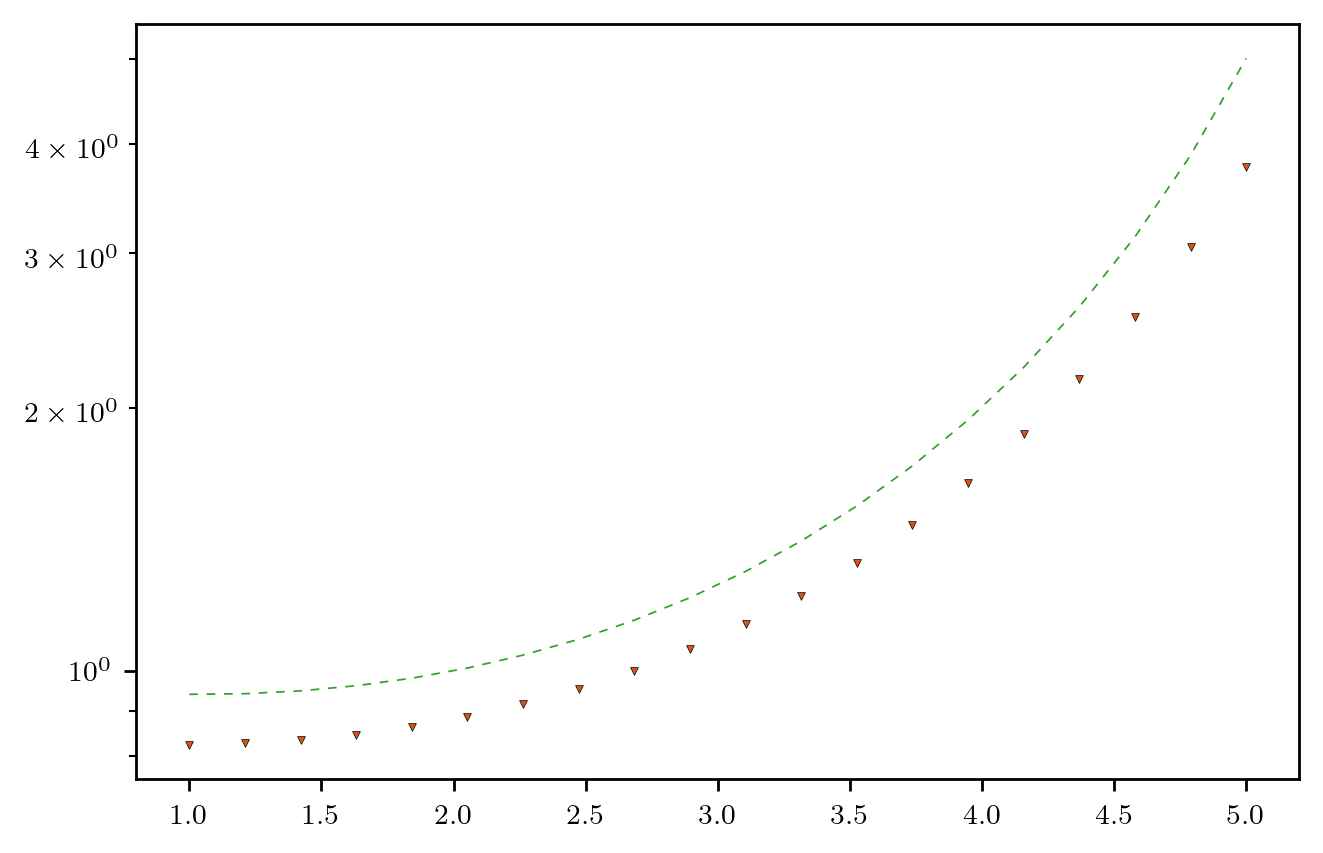

In [50]:
from scipy.special import gamma
aa = -alphas
scaling = 2.**(aa/2.) * gamma(D/2. + 2. - aa/2.) / gamma(D/2. + 2.)
plt.plot(-alphas, scaling - 0., linewidth=0.5, color=c[2], linestyle=(0,(5,5)), zorder=0)

for i in range(len(specs)):
    pk, pfek = Pspecs[i]
    ak, afek = specs[i]
    plt.scatter(-alphas[i], np.nanmean(afek * (dk/twopi)**D * np.sum(np.ones(grid_dims) * dx**D) / pfek), marker='v', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

plt.yscale('log')
#plt.ylim((1e-1, 1e3))